<a href="https://colab.research.google.com/github/DarkLyng/Proyecto_Modelos/blob/main/Proyecto_Modelos_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Preparar datos**

In [55]:
# Bibliotecas de Python

import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import csv

warnings.filterwarnings('ignore')

In [56]:
# Carga el archivo xlsx
xls = pd.ExcelFile("/content/Contoso Sales.xlsx")
print(xls.sheet_names)

['DimChannel', 'DimGeography', 'DimProduct', 'DimProductCategory', 'DimProductSubCategory', 'DimPromotion', 'DimStores']


In [57]:
# Crea una lista con los nombres de las hojas de Contoso Sales
tabs = ['DimChannel', 'DimGeography', 'DimProduct', 'DimProductCategory', 'DimProductSubCategory', 'DimPromotion', 'DimStores']
tablas = []

In [58]:
# Se agrega en la lista los nombres de las hojas del xlsx
for tab in tabs:
  df = pd.read_excel("/content/Contoso Sales.xlsx", sheet_name=tab)
  tablas.append(df)

In [59]:
# Lee el el archivo FactSales, lo separa y agrega a la lista "tablas" los datos del txt
ventas = pd.read_csv("FactSales.txt", sep="\t")
tablas.append(ventas)

In [60]:
# Muestra la cantidad de tablas que se cargaron a la lista
print(f"Total de tablas cargadas en la lista: {len(tablas)}")

Total de tablas cargadas en la lista: 8


# **2. Transformación**

Cambiar dtype de ciertas columnas

In [61]:
df_ventas = tablas[-1]  # Último índice
df_stores = tablas[6]   # Índice 0: Tiendas
df_product= tablas[2]   # Índice 2: Productos

In [62]:
df_ventas['DateKey'] = pd.to_datetime(df_ventas['DateKey'])#, errors='coerce')

In [63]:
df_ventas['ReturnQuantity'] = pd.to_numeric(df_ventas['ReturnQuantity'], errors='coerce').fillna(0).astype(int)

In [64]:
df_ventas['Cantidad_total'] = pd.to_numeric(df_ventas['Cantidad_total'], errors='coerce').fillna(0).astype(int)

In [65]:
df_ventas['Devolución'] = df_ventas['Devolución'].astype(str)

In [66]:
df_ventas['Venta_type'] = df_ventas['Venta_type'].astype(str)

In [67]:
df_ventas['Devolución_type'] = df_ventas['Devolución_type'].astype(str)

In [68]:
df_ventas['Precio_unitario'] = pd.to_numeric(df_ventas['Precio_unitario'], errors='coerce').fillna(0).astype(float)

In [69]:
df_ventas['Ingresos'] = pd.to_numeric(df_ventas['Ingresos'], errors='coerce').fillna(0).astype(float)

Métricas de las Tablas FactSales

In [70]:
cantidad_ventas = df_ventas['SalesQuantity'].sum()
print(f" Cantidad total de ventas (Unidades): {cantidad_ventas:.0f}")

 Cantidad total de ventas (Unidades): 36900410


In [71]:
cantidad_devoluciones = df_ventas['ReturnQuantity'].sum()
print(f" Cantidad total de devoluciones (Unidades): {cantidad_devoluciones:.0f}")

 Cantidad total de devoluciones (Unidades): 326308


In [72]:
cantidad_total = cantidad_ventas - cantidad_devoluciones
print(f" Cantidad total de ventas menos devoluciones (Cantidad Total): {cantidad_total:.0f}")

 Cantidad total de ventas menos devoluciones (Cantidad Total): 36574102


Otras Métricas

In [73]:
promedio_precio_unitario = df_product['UnitPrice'].mean()
print(f" Promedio precio unitario: ₡{promedio_precio_unitario:.2f}")

 Promedio precio unitario: ₡316.92


In [74]:
numero_stores = df_stores['StoreKey'].count()
print(f" Número total de tiendas registradas: {numero_stores:}")

 Número total de tiendas registradas: 310


In [75]:
numero_stores_con_ventas = df_ventas['StoreKey'].nunique()
print(f" Número de tiendas con ventas reales: {numero_stores_con_ventas:,}")

 Número de tiendas con ventas reales: 306


In [76]:
numero_ordenes = len(df_ventas)
print(f" Número total de ordenes procesadas: {numero_ordenes:}")

 Número total de ordenes procesadas: 2282482


In [77]:
numero_ordenes_con_devolucion = len(df_ventas[df_ventas['ReturnQuantity'] > 0])
print(f" Ordenes con devolución: {numero_ordenes_con_devolucion:}")

 Ordenes con devolución: 318550


In [78]:
total_ingresos = df_ventas['Ingresos'].sum()
print(f" Total de ingresos históricos: ₡{total_ingresos:.2f}")

 Total de ingresos históricos: ₡129170161.00


# **3. Carga**

In [79]:
# Comproba por separado el número de columnas y filas del dataframe
tablas[2].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1690 entries, 0 to 1689
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ProductKey             1690 non-null   int64  
 1   ProductName            1690 non-null   object 
 2   ProductDescription     1690 non-null   object 
 3   ProductSubcategoryKey  1690 non-null   int64  
 4   Manufacturer           1690 non-null   object 
 5   BrandName              1690 non-null   object 
 6   ClassID                1690 non-null   int64  
 7   ClassName              1690 non-null   object 
 8   ColorID                1690 non-null   int64  
 9   ColorName              1690 non-null   object 
 10  Size                   1240 non-null   object 
 11  Weight                 1526 non-null   float64
 12  UnitCost               1690 non-null   float64
 13  UnitPrice              1690 non-null   float64
dtypes: float64(3), int64(4), object(7)
memory usage: 185.0+ 

In [80]:
# Muestra la cantidad de filas columnas y datos faltantes del dataframe
print(" Conteo de filas, columnas y datos fantantes \n")

for i, df in enumerate(tablas):
    # Filas y columnas
    filas = df.shape[0]
    columnas = df.shape[1]
    # Total de celdas vacías o con errores en toda la tabla
    celdas_vacias_tot = df.isnull().sum().sum()

    # Nombre original usando la lista tabs
    nombre_tabla = tabs[i] if i < len(tabs) else "FactSales"
    print(f"Índice [{i}] - Tabla: '{nombre_tabla}'")
    print(f" Filas: {filas}")
    print(f" Columnas: {columnas}")
    print(f" Total de celdas vacías o errores encontrados: {celdas_vacias_tot}")
    print("-" * 40)

 Conteo de filas, columnas y datos fantantes 

Índice [0] - Tabla: 'DimChannel'
 Filas: 4
 Columnas: 2
 Total de celdas vacías o errores encontrados: 0
----------------------------------------
Índice [1] - Tabla: 'DimGeography'
 Filas: 674
 Columnas: 3
 Total de celdas vacías o errores encontrados: 3
----------------------------------------
Índice [2] - Tabla: 'DimProduct'
 Filas: 1690
 Columnas: 14
 Total de celdas vacías o errores encontrados: 614
----------------------------------------
Índice [3] - Tabla: 'DimProductCategory'
 Filas: 8
 Columnas: 2
 Total de celdas vacías o errores encontrados: 0
----------------------------------------
Índice [4] - Tabla: 'DimProductSubCategory'
 Filas: 44
 Columnas: 3
 Total de celdas vacías o errores encontrados: 0
----------------------------------------
Índice [5] - Tabla: 'DimPromotion'
 Filas: 28
 Columnas: 7
 Total de celdas vacías o errores encontrados: 0
----------------------------------------
Índice [6] - Tabla: 'DimStores'
 Filas: 310


In [106]:
# Función que permite obtener un análisis estadístico de cada hoja de Contoso Sales

def analizar_tabla_lista(df, nombre_tabla):
    print(f"Análisis de la tabla: {nombre_tabla}")

    for col in df.columns:
        dtype = df[col].dtype
        total_valores = len(df[col])
        valores_unicos = df[col].nunique()
        faltantes = df.isnull().sum().sum()

        print(f"\n Columna: '{col}' | Tipo: {dtype}")
        print(f"  - Datos faltantes: {faltantes} ({ (faltantes/total_valores)*100:.2f}%)")
        print(f"  - Cardinalidad (Valores únicos): {valores_unicos}")

        # Variables numéricas continuas o cuantitativas
        if np.issubdtype(dtype, np.number) and valores_unicos > 10:
            print("  - Clasificación: Variable numérica continua")

            media = df[col].mean()
            q1 = df[col].quantile(0.25)   # Primer Cuartil (25%)
            mediana = df[col].median()
            q3 = df[col].quantile(0.75)   # Tercer Cuartil (75%)
            desv_est = df[col].std()
            varianza = df[col].var()
            inclinacion = df[col].skew()  # Inclinación(Skewness)
            curtosis = df[col].kurt()     # Kurtosis
            val_min = df[col].min()
            val_max = df[col].max()
            # Cálculo de los outliers
            ric = q3 - q1
            limite_inferior_outlier = q1 - 1.5 * ric
            limite_superior_outlier = q3 + 1.5 * ric

            print(f"  - Valor esperado (Media): {media:.4f}")
            print(f"  - Cuartil 1 (Q1 - 25%): {q1:.4f}")
            print(f"  - Mediana: {mediana:.4f}")
            print(f"  - Cuartil 3 (Q3 - 75%): {q3:.4f}")
            print(f"  - Varianza: {varianza:.4f}")
            print(f"  - Desviación estándar: {desv_est:.4f}")
            print(f"  - Inclinación (Skewness): {inclinacion:.4f}")
            print(f"  - Kurtosis: {curtosis:.4f}")

            if abs(inclinacion) < 0.5:
                  print("  -  Distribución simétrica.")
            else:
                print(f"  - Distribución asimétrica a la {'derecha' if inclinacion > 0 else 'izquierda'}.")

            print(f"  - Valor mínimo: {val_min:.4f}")
            print(f"  - Valor máximo: {val_max:.4f}")
            print(f"  - Rango intercuartílico (RIC): {ric:.4f}")
            print(f"  - Límites para outliers: [{limite_inferior_outlier:.2f} , {limite_superior_outlier:.2f}]")

        # Variables discretas o cualitativas (Frecuencia y probabilidad empírica)
        else:
            print("  - Clasificación: Variable cualitativa o discreta")
            frecuencias = df[col].value_counts(dropna=False).head(5)
            probabilidades = df[col].value_counts(dropna=False, normalize=True).head(5)

            print("  - Los 5 valores con mayor frecuencia y probabilidad empírica P(X=x):")
            for val, freq in frecuencias.items():
                prob = probabilidades[val]
                print(f"     Valor: {val} | Frecuencia: {freq} | Probabilidad: {prob:.4f} ({prob*100:.2f}%)")



In [82]:
# Se analiza por índices
# Analiza la tabla DimChannel
analizar_tabla_lista(tablas[0], "DimChannel")


Análisis de la tabla: DimChannel

 Columna: 'ChannelKey' | Tipo: int64
  - Datos faltantes: 0 (0.00%)
  - Cardinalidad (Valores únicos): 4
  - Clasificación: Variable cualitativa o discreta
  - Los 5 valores con mayor frecuencia y probabilidad empírica P(X=x):
     Valor: 1 | Frecuencia: 1 | Probabilidad: 0.2500 (25.00%)
     Valor: 2 | Frecuencia: 1 | Probabilidad: 0.2500 (25.00%)
     Valor: 3 | Frecuencia: 1 | Probabilidad: 0.2500 (25.00%)
     Valor: 4 | Frecuencia: 1 | Probabilidad: 0.2500 (25.00%)

 Columna: 'ChannelName' | Tipo: object
  - Datos faltantes: 0 (0.00%)
  - Cardinalidad (Valores únicos): 4
  - Clasificación: Variable cualitativa o discreta
  - Los 5 valores con mayor frecuencia y probabilidad empírica P(X=x):
     Valor: Store | Frecuencia: 1 | Probabilidad: 0.2500 (25.00%)
     Valor: Online | Frecuencia: 1 | Probabilidad: 0.2500 (25.00%)
     Valor: Catalog | Frecuencia: 1 | Probabilidad: 0.2500 (25.00%)
     Valor: Reseller | Frecuencia: 1 | Probabilidad: 0.2500 

In [83]:
# Analiza la tabla DimGeography
#analizar_tabla_lista(tablas[1], "DimGeography")

In [84]:
# Analiza la tabla DimProduct
#analizar_tabla_lista(tablas[2], "DimProduct")

In [85]:
# Analiza la tabla DimProductCategory
#analizar_tabla_lista(tablas[3], "DimProductCategory")

In [86]:
# Analiza la tabla DimProductSubCategory
#analizar_tabla_lista(tablas[4], "DimProductSubCategory")

In [87]:
# Analiza la tabla DimPromotion
#analizar_tabla_lista(tablas[5], "DimPromotion")

In [88]:
# Analiza la tabla DimStores
#analizar_tabla_lista(tablas[6], "DimStores")

In [89]:
# Analiza la tabla FactSales (Último índice de la lista)
# analizar_tabla_lista(tablas[-1], "FactSales")

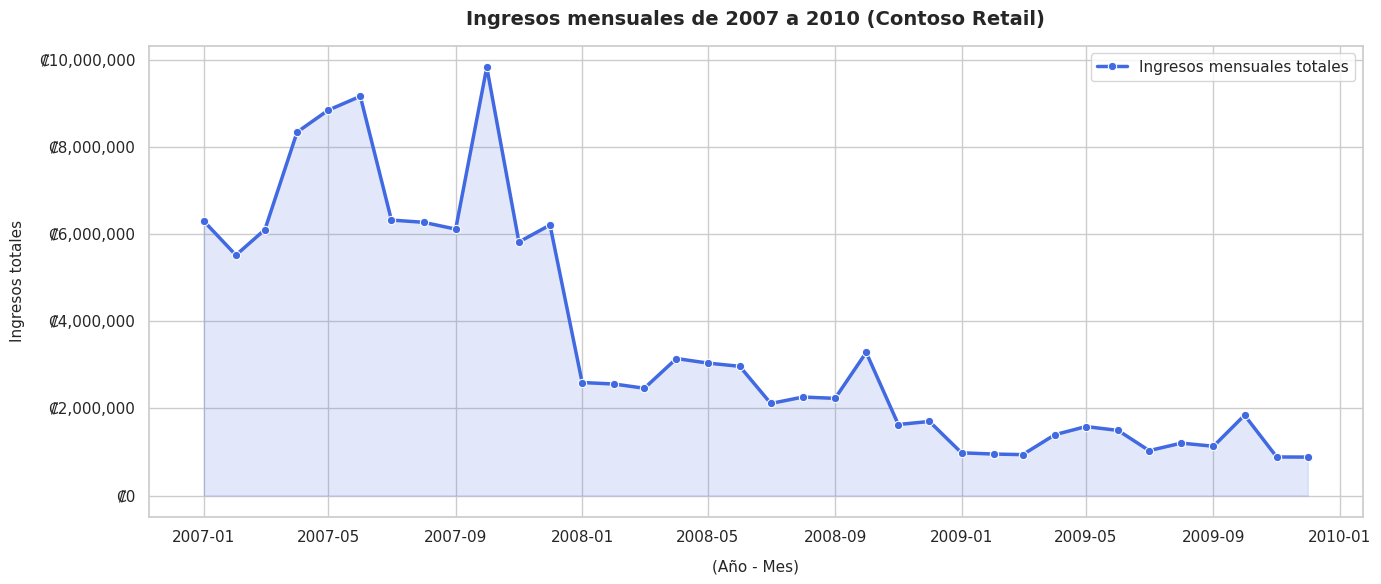

In [90]:
# Columna que combina año y mes en formato de "Período" y los ordena cronológicamente
df_ventas["AñoMes"] = df_ventas["DateKey"].dt.to_period("M")

# Suma los ingresos totales para cada mes a lo largo de los años
evolucion_mensual = df_ventas.groupby("AñoMes")["Ingresos"].sum().reset_index()

# Convierte el nuevo período en tipo fecha para que matplotlib lo pueda graficar
evolucion_mensual["AñoMes"] = evolucion_mensual["AñoMes"].dt.to_timestamp()

# Estilo visual con seaborn
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 6))

# Línea de tendencia y los puntos en cada mes
sns.lineplot(data=evolucion_mensual, x="AñoMes", y="Ingresos", color="royalblue", linewidth=2.5, marker="o", markersize=6, label="Ingresos mensuales totales")

# Sombreado debajo de la curva
plt.fill_between(evolucion_mensual["AñoMes"], evolucion_mensual["Ingresos"], color="royalblue", alpha=0.15)

# Etiquetas y títulos
plt.title("Ingresos mensuales de 2007 a 2010 (Contoso Retail)", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("(Año - Mes)", fontsize=11, labelpad=10)
plt.ylabel("Ingresos totales", fontsize=11, labelpad=10)

# Muestra en el eje y los números en millones y miles
valores_y = plt.gca().get_yticks()
plt.gca().set_yticklabels([f"₡{x:,.0f}" for x in valores_y])

plt.tight_layout()
plt.show()

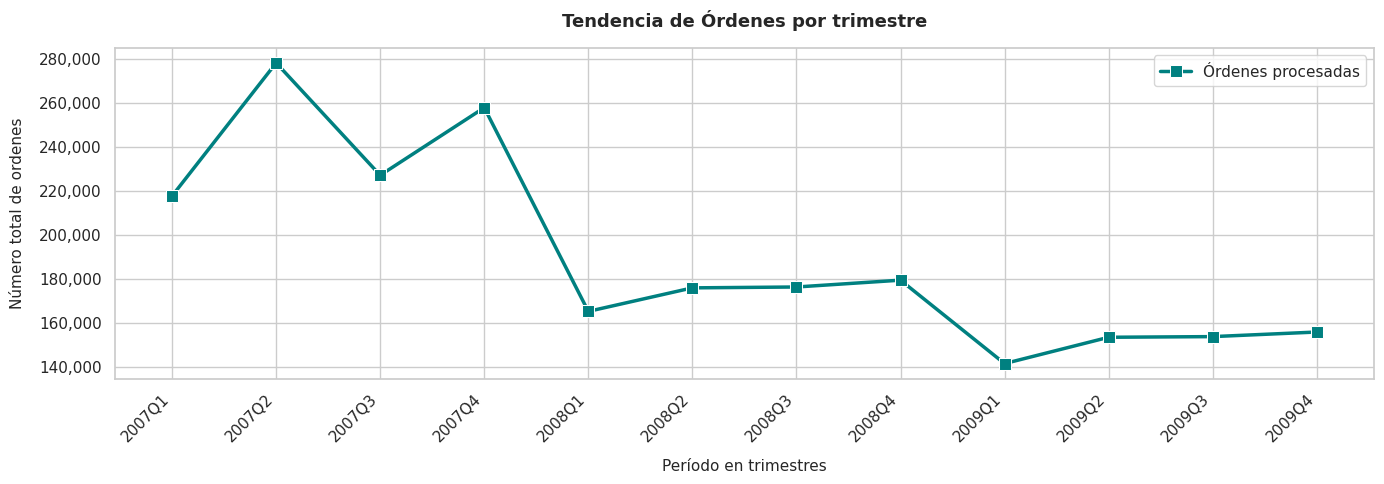

In [101]:
# Se extrae el año y trimestre 2007Q2, 2009Q3
df_ventas["Trimestre"] = df_ventas["DateKey"].dt.to_period("Q")

# Número total órdenes por trimestre
ordenes_trimestre = df_ventas.groupby("Trimestre").size().reset_index(name="Cantidad_Ordenes")
ordenes_trimestre['Trimestre'] = ordenes_trimestre['Trimestre'].astype(str)

plt.figure(figsize=(14, 5))
sns.set_theme(style="whitegrid")

sns.lineplot(data=ordenes_trimestre, x="Trimestre", y="Cantidad_Ordenes", marker="s", markersize=8, color="teal", linewidth=2.5, label="Órdenes procesadas")

plt.title("Tendencia de Órdenes por trimestre", fontsize=13, fontweight="bold", pad=15)
plt.xlabel("Período en trimestres", fontsize=11, labelpad=10)
plt.ylabel("Número total de ordenes", fontsize=11, labelpad=10)
plt.xticks(rotation=45, ha="right")

# Cambia el eje Y con separadores de miles
plt.gca().get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, p: f"{x:,.0f}"))

plt.tight_layout()
plt.show()

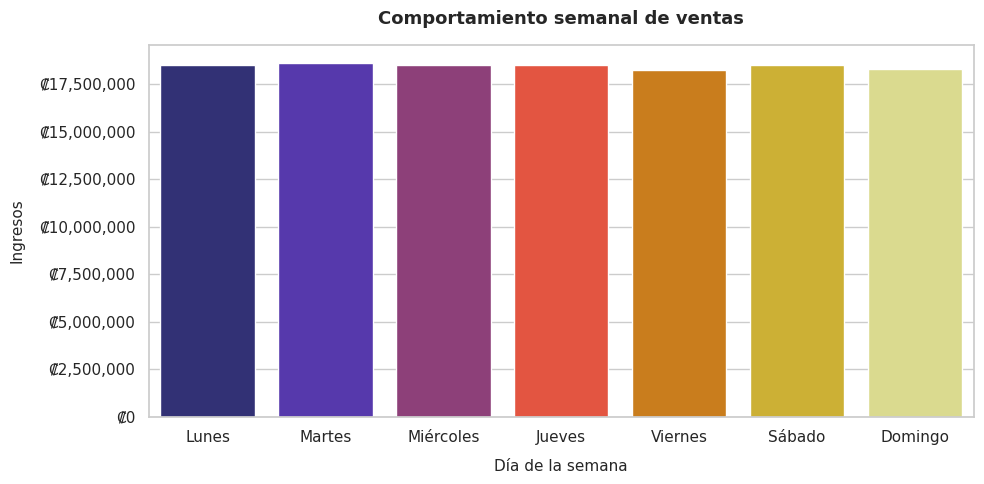

In [105]:
# Se obtiene el número de día y el nombre del día,  0 (Lunes) a 6 (Domingo)
df_ventas["Dia_Numero"] = df_ventas["DateKey"].dt.dayofweek

# Pasamos los números a español
dias_esp = {0:"Lunes", 1:"Martes", 2:"Miércoles", 3:"Jueves", 4:"Viernes", 5:"Sábado", 6:"Domingo"}
df_ventas["Dia_Nombre"] = df_ventas["Dia_Numero"].map(dias_esp)

# Agrupamos por número y nombre para mantener el orden de la semana
ventas_dia_semana = df_ventas.groupby(["Dia_Numero", "Dia_Nombre"])["Ingresos"].sum().reset_index()

plt.figure(figsize=(10, 5))

# Gráfico de barras
sns.barplot(data=ventas_dia_semana, x="Dia_Nombre", y="Ingresos", palette="CMRmap", hue="Dia_Nombre", legend=False)

plt.title("Comportamiento semanal de ventas", fontsize=13, fontweight="bold", pad=15)
plt.xlabel("Día de la semana", fontsize=11, labelpad=10)
plt.ylabel("Ingresos", fontsize=11, labelpad=10)

plt.gca().get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, p: f"₡{x:,.0f}"))

plt.tight_layout()
plt.show()

In [93]:
# Otra forma de obtener los valores atípicos, limites, cuartiles, etc
#print(tablas[7]["SalesQuantity"].describe())

In [94]:
#tablas[7]["SalesQuantity"].plot.kde()
#plt.xlim([0,50])

In [95]:
#tablas[6]["GeographyKey"].hist()

In [96]:
#print(tablas[6]["GeographyKey"].head())

In [97]:
#df_ventas.to_csv('FactSales_Procesado.csv', index=False, sep='\t')

In [98]:
#files.download('FactSales_Procesado.csv')